<a href="https://colab.research.google.com/github/shreyashbhat1111/ML_Intern/blob/main/ML_WEEK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Housing Model R² Score: 0.3707569232254778


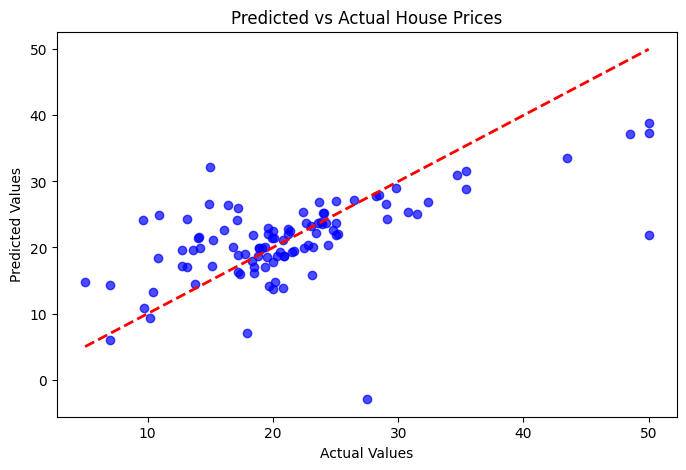

In [2]:
# Cell 1: Week 2 Assignment 1 & Mini Project 2 - Linear Regression on Housing Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import fetch_openml

# Load Housing dataset using fetch_openml
# The Boston Housing dataset from its original source has ethical concerns, leading to its deprecation
# in scikit-learn's direct load functions. We can fetch it from OpenML instead.
boston = fetch_openml(name='boston', version=1, as_frame=True, return_X_y=False)
housing_df = boston.data
housing_df['medv'] = boston.target # Add the target column to the DataFrame

# Select features (e.g., 'rm' - average rooms) and target ('medv' - median value)
# Note: Feature 'rm' from OpenML is 'RM' (capitalized). Target 'medv' is 'MEDV'.
X = housing_df[['RM']] # Use 'RM' as it comes from fetch_openml
y = housing_df['medv'] # This should work after adding boston.target as 'medv'

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict house prices and evaluate R² score
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'Housing Model R² Score: {r2}')

# Plot predicted vs actual values (Mini Project Task)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2
)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual House Prices')
plt.show()

In [3]:
# Cell 2: Week 2 Assignment 2 - Logistic Regression on Titanic Dataset for Survival Prediction
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset
titanic_url = (
    'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
)
titanic_df = pd.read_csv(titanic_url)

# Basic preprocessing (handling missing age and encoding gender)
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median())
le = LabelEncoder()
titanic_df['Sex'] = le.fit_transform(titanic_df['Sex'])

# Select features and target for classification
X_titanic = titanic_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y_titanic = titanic_df['Survived']

# Train/Test Split
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42
)

# Train Logistic Regression model
log_model = LogisticRegression(max_iter=200)
log_model.fit(Xt_train, yt_train)

# Predict and check accuracy
yt_pred = log_model.predict(Xt_test)
print(f'Logistic Regression Accuracy: {accuracy_score(yt_test, yt_pred)}')
print('\nClassification Report:\n', classification_report(yt_test, yt_pred))

Logistic Regression Accuracy: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

